# Strain Analysis (multi-feed, slow-mo aware)

Loads a tracking CSV and:
1. Plots Δx vs **real** time (corrected for slow-motion playback if needed)
2. Detects **all** feed events and produces a filtered plot with every feed removed
3. Prints the measured distance of each feed
4. Prints the permanent strain (end of filtered curve − start of filtered curve)

Edit `CSV_PATH` and check `SLOWMO_FACTOR` in the first code cell, then run all cells.

In [64]:
# ====== EDIT THIS ======
CSV_PATH       = r"C:\Users\joaki\Desktop\DTU\Trelleborg\svend\strain_tracking_2026-05-21T13-10-11.csv"  # path to your CSV file (use r"..." for Windows paths)
EXPECTED_FEED  = 3.0                    # nominal feed distance, in the CSV's units
STABLE_WINDOW  = 0.1                    # seconds — averaging window for stable regions (in REAL time)
MIN_FEED_FRAC  = 0.3                    # ignore moves smaller than this fraction of EXPECTED_FEED

# --- Time correction ---
# The CSV's time column is computed from the video's playback timeline, not real time.
# Phones store slow-mo at ~30 fps playback even when the capture rate was higher,
# so the CSV time axis ends up stretched. Divide it back down by the slow-mo factor:
#   120 fps capture → 30 fps playback : SLOWMO_FACTOR = 4
#   240 fps capture → 30 fps playback : SLOWMO_FACTOR = 8
#   real-time video, no slow-mo       : SLOWMO_FACTOR = 1
#
# (Formally: SLOWMO_FACTOR = capture_fps / playback_fps_of_file)
SLOWMO_FACTOR  = 4
# =======================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [65]:
# ---- Multi-feed detection ----
def detect_feeds(t, x, expected_feed=3.0, stable_window_s=0.3,
                 smooth_s=0.05, min_feed_fraction=0.5):
    """Return a chronologically-ordered list of feed events."""
    n = len(t)
    if n < 5:
        return []
    dt = float(np.median(np.diff(t)))
    smooth_n = max(3, int(smooth_s / dt))

    x_smooth = pd.Series(x).rolling(smooth_n, center=True, min_periods=1).mean().to_numpy()
    v = np.gradient(x_smooth, t)
    abs_v = np.abs(v)
    peak_v = float(np.max(abs_v))
    if peak_v == 0:
        return []
    threshold = 0.30 * peak_v
    moving = abs_v > threshold

    regions, i = [], 0
    while i < n:
        if moving[i]:
            j = i
            while j < n and moving[j]:
                j += 1
            regions.append((i, j - 1))
            i = j
        else:
            i += 1
    if not regions:
        return []

    min_disp = min_feed_fraction * abs(expected_feed)
    significant = [r for r in regions if abs(x[r[1]] - x[r[0]]) >= min_disp]
    significant.sort(key=lambda r: r[0])
    if not significant:
        return []

    win = max(3, int(stable_window_s / dt))
    feeds = []
    for k, (fs, fe) in enumerate(significant):
        prev_end   = significant[k - 1][1] if k > 0 else -1
        next_start = significant[k + 1][0] if k < len(significant) - 1 else n

        bs  = max(prev_end + 1, fs - win)
        be  = fs
        as_ = fe + 1
        ae  = min(next_start, fe + 1 + win)
        if be <= bs or ae <= as_:
            continue

        feeds.append({
            "feed_start":    fs, "feed_end": fe,
            "before_stable": float(np.mean(x[bs:be])),
            "after_stable":  float(np.mean(x[as_:ae])),
            "before_range":  (bs, be),
            "after_range":   (as_, ae),
        })
    return feeds

In [66]:
# ---- Load CSV and apply slow-mo time correction ----
df = pd.read_csv(CSV_PATH, comment="#")

dx_cols = [c for c in df.columns if c.startswith("dx_") and c != "dx_px"]
if dx_cols:
    dx_col = dx_cols[0]
elif "dx_px" in df.columns:
    dx_col = "dx_px"
    print("NOTE: no calibrated column found; using dx_px (pixels).")
else:
    raise ValueError(f"No dx_ column found. Columns: {list(df.columns)}")

unit  = dx_col.split("_", 1)[1]
t_raw = df["time_s"].to_numpy()
t     = t_raw / SLOWMO_FACTOR              # <-- the fix: real time, not playback time
x     = df[dx_col].to_numpy()

print(f"Loaded {len(df)} rows from {CSV_PATH}")
print(f"Using column: {dx_col}   (unit: {unit})")
print(f"CSV (playback) time range: {t_raw[0]:.3f} → {t_raw[-1]:.3f} s")
print(f"Real time range (÷ {SLOWMO_FACTOR}):    {t[0]:.3f} → {t[-1]:.3f} s")
print(f"  → If this doesn't match your real-life recording duration, adjust SLOWMO_FACTOR.")
print(f"Δx range:   {x.min():.3f} → {x.max():.3f} {unit}")

Loaded 1836 rows from C:\Users\joaki\Desktop\DTU\Trelleborg\svend\strain_tracking_2026-05-21T13-10-11.csv
Using column: dx_mm   (unit: mm)
CSV (playback) time range: 0.000 → 15.292 s
Real time range (÷ 4):    0.000 → 3.823 s
  → If this doesn't match your real-life recording duration, adjust SLOWMO_FACTOR.
Δx range:   -0.008 → 12.469 mm


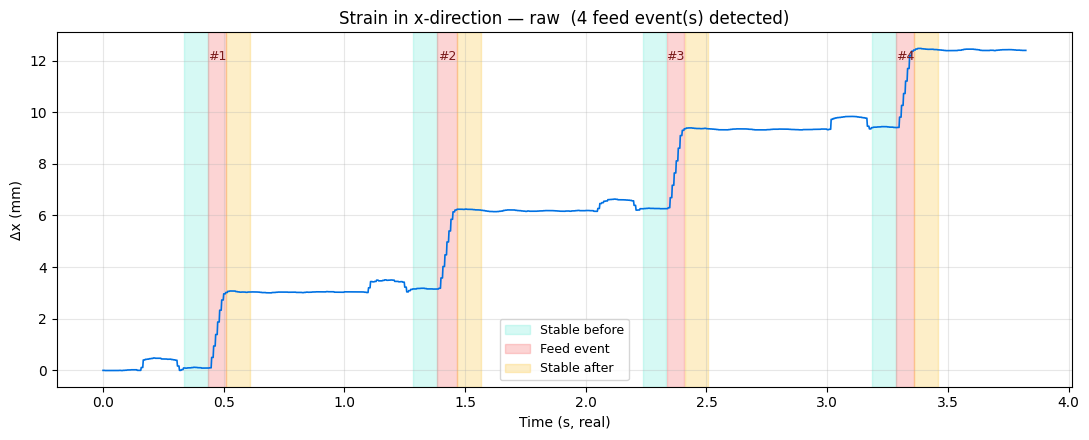

In [67]:
# ---- Plot 1: raw with all detected feed events highlighted ----
feeds = detect_feeds(t, x, expected_feed=EXPECTED_FEED,
                     stable_window_s=STABLE_WINDOW, min_feed_fraction=MIN_FEED_FRAC)

fig1, ax1 = plt.subplots(figsize=(11, 4.5))
ax1.plot(t, x, color="#0071e3", linewidth=1.2)
ax1.set_xlabel("Time (s, real)")
ax1.set_ylabel(f"Δx ({unit})")
ax1.set_title(f"Strain in x-direction — raw  ({len(feeds)} feed event(s) detected)")
ax1.grid(True, alpha=0.3)

for k, f in enumerate(feeds):
    bs, be = f["before_range"]
    as_, ae = f["after_range"]
    fs, fe = f["feed_start"], f["feed_end"]
    ax1.axvspan(t[bs], t[be - 1], color="#5eead4", alpha=0.25,
                label="Stable before" if k == 0 else None)
    ax1.axvspan(t[fs], t[fe],     color="#f87171", alpha=0.30,
                label="Feed event"    if k == 0 else None)
    ax1.axvspan(t[as_], t[ae - 1], color="#fbbf24", alpha=0.25,
                label="Stable after"  if k == 0 else None)
    yt = ax1.get_ylim()[1] - 0.05 * (ax1.get_ylim()[1] - ax1.get_ylim()[0])
    ax1.text((t[fs] + t[fe]) / 2, yt, f"#{k+1}",
             ha="center", va="top", fontsize=9, color="#7a1a1a")

if feeds:
    ax1.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.show()

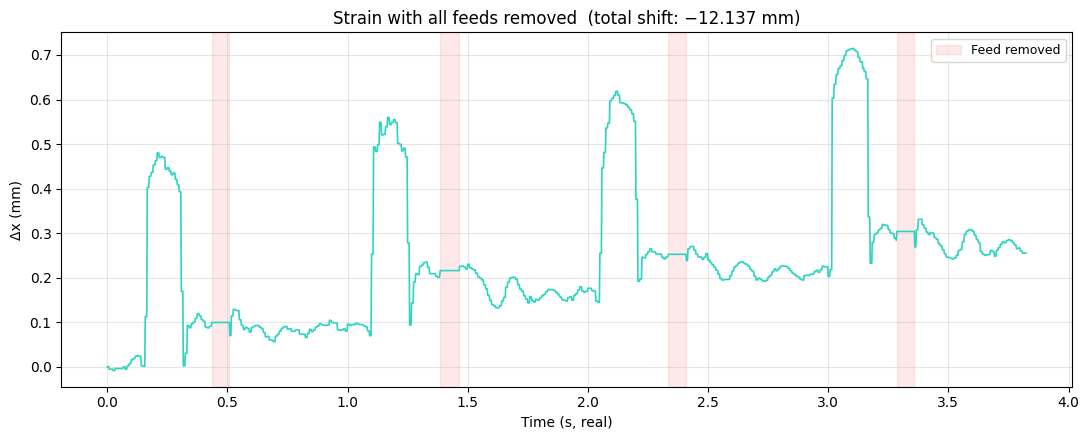

In [68]:
# ---- Build filtered signal (subtract every feed cumulatively) ----
x_filtered = x.copy()
cumulative_shift = 0.0
feed_distances = []

for f in feeds:
    feed_distance = f["after_stable"] - f["before_stable"]
    feed_distances.append(feed_distance)
    x_filtered[f["feed_end"] + 1:] -= feed_distance
    x_filtered[f["feed_start"]:f["feed_end"] + 1] = f["before_stable"] - cumulative_shift
    cumulative_shift += feed_distance

fig2, ax2 = plt.subplots(figsize=(11, 4.5))
ax2.plot(t, x_filtered, color="#2dd4bf", linewidth=1.2)
for k, f in enumerate(feeds):
    ax2.axvspan(t[f["feed_start"]], t[f["feed_end"]], color="#f87171", alpha=0.15,
                label="Feed removed" if k == 0 else None)
if feeds:
    ax2.legend(loc="best", fontsize=9)
ax2.set_xlabel("Time (s, real)")
ax2.set_ylabel(f"Δx ({unit})")
ax2.set_title(f"Strain with all feeds removed  (total shift: −{cumulative_shift:.3f} {unit})")
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [69]:
# ---- Results ----
dt = float(np.median(np.diff(t)))
win = max(3, int(STABLE_WINDOW / dt))
first_stable     = float(np.mean(x_filtered[:win]))
last_stable      = float(np.mean(x_filtered[-win:]))
permanent_strain = last_stable - first_stable

bar = "─" * 70
print(bar)
print("  STRAIN ANALYSIS")
print(bar)
print(f"  Slow-mo factor applied:  {SLOWMO_FACTOR}")
print(f"  Real time range:         {t[0]:.3f} → {t[-1]:.3f} s")
print()
if feeds:
    print(f"  {len(feeds)} feed event(s) detected (expected ≈ {EXPECTED_FEED:+.3f} {unit} each)\n")
    print(f"  {'#':>3}  {'t_start':>8}  {'t_end':>8}  {'before':>10}  {'after':>10}  {'feed':>10}")
    for k, (f, d) in enumerate(zip(feeds, feed_distances), 1):
        fs, fe = f["feed_start"], f["feed_end"]
        print(f"  {k:>3}  {t[fs]:>8.3f}  {t[fe]:>8.3f}  "
              f"{f['before_stable']:>+10.4f}  {f['after_stable']:>+10.4f}  {d:>+10.4f}")
    print(f"\n  Sum of feed distances:   {sum(feed_distances):+.4f} {unit}")
else:
    print("  No feed events detected.")
print()
print(f"  First stable (filtered): {first_stable:+.4f} {unit}")
print(f"  Last  stable (filtered): {last_stable:+.4f} {unit}")
print(f"  Permanent strain:        {permanent_strain:+.4f} {unit}")
print(bar)

──────────────────────────────────────────────────────────────────────
  STRAIN ANALYSIS
──────────────────────────────────────────────────────────────────────
  Slow-mo factor applied:  4
  Real time range:         0.000 → 3.823 s

  4 feed event(s) detected (expected ≈ +3.000 mm each)

    #   t_start     t_end      before       after        feed
    1     0.435     0.508     +0.0996     +3.0460     +2.9464
    2     1.385     1.465     +3.1624     +6.2316     +3.0692
    3     2.335     2.408     +6.2682     +9.3735     +3.1053
    4     3.285     3.358     +9.4248    +12.4412     +3.0164

  Sum of feed distances:   +12.1373 mm

  First stable (filtered): -0.0025 mm
  Last  stable (filtered): +0.2723 mm
  Permanent strain:        +0.2747 mm
──────────────────────────────────────────────────────────────────────


In [70]:
# ---- Cut (knife) event detection on filtered signal ----
# Each knife cut in the filtered signal looks like:
#   1. A fast RISE  → elongation as knife pushes in   (Δ_elong)
#   2. A fast FALL  → contraction as knife is removed  (Δ_contract)
# We isolate the 'quick elastic region' by looking only at the steep
# up/down transients, ignoring the slow creep in between.

def detect_cuts(t, x_filt, smooth_s=0.05, vel_threshold_frac=0.05,
                min_cut_amplitude=0.1, stable_window_s=0.05,
                merge_gap_s=0.03):
    """
    Detect knife cut events in the feed-filtered strain signal.

    Each detected cut returns:
      - rise_start / rise_end  : index range of the fast elongation transient
      - fall_start / fall_end  : index range of the fast contraction transient
      - baseline               : mean level just before the rise
      - peak                   : mean level at the plateau between rise and fall
      - trough                 : mean level just after the fall
      - delta_elongation       : peak  − baseline  (should be > 0)
      - delta_contraction      : trough − peak     (should be < 0)
      - net_permanent          : trough − baseline (residual set after cut)
    """
    n = len(t)
    dt = float(np.median(np.diff(t)))

    # Smooth for velocity computation
    sn = max(3, int(smooth_s / dt))
    xs = pd.Series(x_filt).rolling(sn, center=True, min_periods=1).mean().to_numpy()
    v = np.gradient(xs, t)

    peak_v = float(np.max(np.abs(v)))
    if peak_v == 0:
        return []
    thr = vel_threshold_frac * peak_v

    # Collect signed motion regions
    def get_regions(mask):
        regs, i = [], 0
        while i < n:
            if mask[i]:
                j = i
                while j < n and mask[j]:
                    j += 1
                regs.append((i, j - 1))
                i = j
            else:
                i += 1
        return regs

    rising  = get_regions(v >  thr)
    falling = get_regions(v < -thr)

    # Filter by amplitude
    sw = max(3, int(stable_window_s / dt))
    rising  = [r for r in rising  if (xs[r[1]] - xs[r[0]]) >=  min_cut_amplitude]
    falling = [r for r in falling if (xs[r[0]] - xs[r[1]]) >=  min_cut_amplitude]

    # Pair each rise with the next fall
    cuts = []
    used_falls = set()
    for rs, re in rising:
        # Find the nearest fall that starts after this rise ends
        candidates = [(i, (fs, fe)) for i, (fs, fe) in enumerate(falling)
                      if fs > re and i not in used_falls]
        if not candidates:
            continue
        fi, (fs, fe) = min(candidates, key=lambda c: c[1][0])
        used_falls.add(fi)

        # Baseline: stable window before the rise
        b0 = max(0, rs - sw)
        baseline = float(np.mean(x_filt[b0:rs])) if rs > b0 else float(x_filt[rs])

        # Peak: stable window between rise-end and fall-start
        p0, p1 = re + 1, fs
        peak = float(np.mean(x_filt[p0:p1])) if p1 > p0 else float(x_filt[re])

        # Trough: stable window after the fall
        t0 = fe + 1
        t1 = min(n, t0 + sw)
        trough = float(np.mean(x_filt[t0:t1])) if t1 > t0 else float(x_filt[fe])

        delta_elong    =  peak   - baseline
        delta_contract =  trough - peak
        net_permanent  =  trough - baseline

        cuts.append({
            "rise_start": rs, "rise_end": re,
            "fall_start": fs, "fall_end": fe,
            "baseline":          baseline,
            "peak":              peak,
            "trough":            trough,
            "delta_elongation":  delta_elong,
            "delta_contraction": delta_contract,
            "net_permanent":     net_permanent,
        })

    return cuts


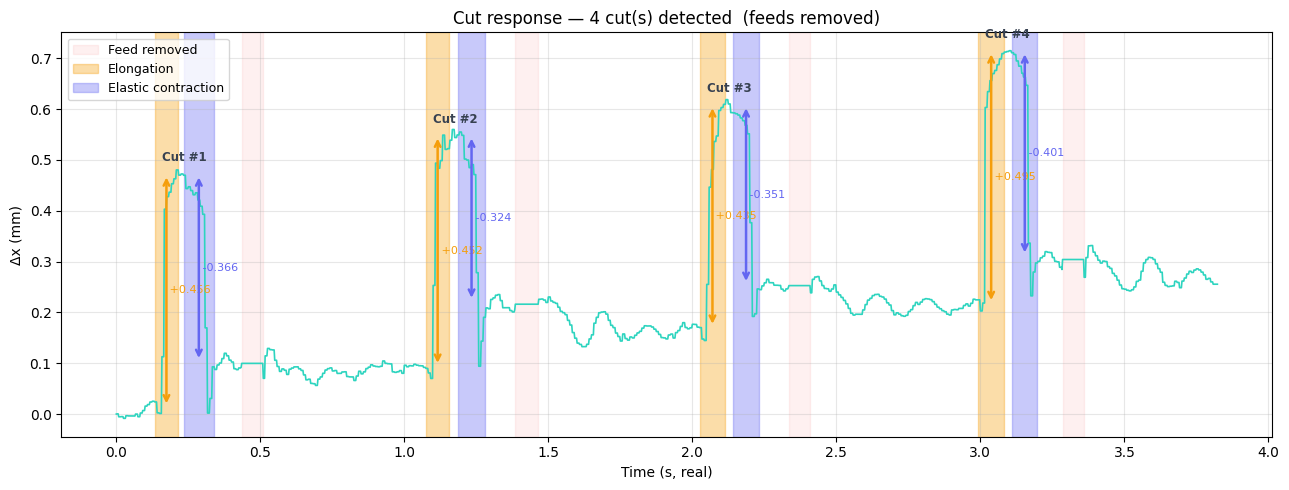

In [71]:
# ---- Detect cuts and plot annotated filtered signal ----
cuts = detect_cuts(t, x_filtered)

fig3, ax3 = plt.subplots(figsize=(13, 5))
ax3.plot(t, x_filtered, color="#2dd4bf", linewidth=1.2, zorder=3)

# Feed-removed bands (light background)
for k, f in enumerate(feeds):
    ax3.axvspan(t[f["feed_start"]], t[f["feed_end"]], color="#f87171", alpha=0.10,
                label="Feed removed" if k == 0 else None)

colors_rise = "#f59e0b"
colors_fall = "#6366f1"

for k, c in enumerate(cuts):
    rs, re = c["rise_start"], c["rise_end"]
    fs2, fe2 = c["fall_start"], c["fall_end"]

    # Shade the elastic transient regions
    ax3.axvspan(t[rs], t[re], color=colors_rise, alpha=0.35,
                label="Elongation" if k == 0 else None)
    ax3.axvspan(t[fs2], t[fe2], color=colors_fall, alpha=0.35,
                label="Elastic contraction" if k == 0 else None)

    # Horizontal reference lines: baseline, peak, trough
    x_mid_rise = (t[rs] + t[re]) / 2
    x_mid_fall = (t[fs2] + t[fe2]) / 2

    # Annotate Δ_elong as a vertical arrow on the rise
    ax3.annotate(
        "", xy=(x_mid_rise, c["peak"]), xytext=(x_mid_rise, c["baseline"]),
        arrowprops=dict(arrowstyle="<->", color=colors_rise, lw=1.8)
    )
    ax3.text(x_mid_rise, (c["baseline"] + c["peak"]) / 2,
             f" +{c['delta_elongation']:.3f}", color=colors_rise,
             fontsize=8, va="center", ha="left")

    # Annotate Δ_contract as a vertical arrow on the fall
    ax3.annotate(
        "", xy=(x_mid_fall, c["trough"]), xytext=(x_mid_fall, c["peak"]),
        arrowprops=dict(arrowstyle="<->", color=colors_fall, lw=1.8)
    )
    ax3.text(x_mid_fall, (c["peak"] + c["trough"]) / 2,
             f" {c['delta_contraction']:.3f}", color=colors_fall,
             fontsize=8, va="center", ha="left")

    # Cut number label at top
    t_label = (t[rs] + t[fe2]) / 2
    ymax = ax3.get_ylim()[1]
    ax3.text(t_label, c["peak"] + 0.02, f"Cut #{k+1}",
             ha="center", va="bottom", fontsize=8.5, fontweight="bold", color="#374151")

ax3.set_xlabel("Time (s, real)")
ax3.set_ylabel(f"Δx ({unit})")
ax3.set_title(f"Cut response — {len(cuts)} cut(s) detected  "
              f"(feeds removed)")
ax3.legend(loc="upper left", fontsize=9)
ax3.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [82]:
# ---- Cut analysis results ----
bar = "─" * 82
print(bar)
print("  CUT (KNIFE) ELASTIC ANALYSIS")
print(bar)
if cuts:
    hdr = (f"  {'#':>3}  {'t_rise':>8}  {'t_fall':>8}  "
           f"{'baseline':>10}  {'peak':>10}  {'trough':>10}  "
           f"{'Δ_elong':>10}  {'Δ_contract':>11}  {'net_set':>10} {'eps_residual':>10} {'stress':>10} {'force':>10}")
    print(hdr)
    print("  " + "─" * 79)
    for k, c in enumerate(cuts, 1):
        print(
            f"  {k:>3}  "
            f"{t[c['rise_start']]:>8.3f}  "
            f"{t[c['fall_start']]:>8.3f}  "
            f"{c['baseline']:>+10.4f}  "
            f"{c['peak']:>+10.4f}  "
            f"{c['trough']:>+10.4f}  "
            f"{(c['delta_elongation']):>+10.4f}  "
            f"{(c['delta_contraction']):>+11.4f}  "
            f"{c['net_permanent']:>+10.4f}"
            f"{((c['delta_elongation'] - c['delta_contraction'])/3):>+10.4f}  "
            f"{(c['delta_elongation'] / 200 *900):>+10.4f}  "
            f"{(c['delta_elongation'] / 200 *900*8.47):>+10.4f}  "
        )
    print()
    elong_vals    = [c['delta_elongation']  for c in cuts]
    contract_vals = [c['delta_contraction'] for c in cuts]
    net_vals      = [c['net_permanent']     for c in cuts]
    print(f"  Mean Δ_elongation  : {np.mean(elong_vals):>+.4f} {unit}  "
          f"(std: {np.std(elong_vals):.4f})")
    print(f"  Mean Δ_contraction : {np.mean(contract_vals):>+.4f} {unit}  "
          f"(std: {np.std(contract_vals):.4f})")
    print(f"  Mean net set       : {np.mean(net_vals):>+.4f} {unit}  "
          f"(std: {np.std(net_vals):.4f})")
    print(f"  Elastic recovery % : "
          f"{100*abs(np.mean(contract_vals)/np.mean(elong_vals)):.1f} % "
          f"(|Δ_contract| / Δ_elong)")
else:
    print("  No cut events detected. Try lowering `vel_threshold_frac` or")
    print("  `min_cut_amplitude` in the detect_cuts() call above.")
print(bar)


──────────────────────────────────────────────────────────────────────────────────
  CUT (KNIFE) ELASTIC ANALYSIS
──────────────────────────────────────────────────────────────────────────────────
    #    t_rise    t_fall    baseline        peak      trough     Δ_elong   Δ_contract     net_set eps_residual     stress      force
  ───────────────────────────────────────────────────────────────────────────────
    1     0.133     0.233     +0.0153     +0.4711     +0.1046     +0.4558      -0.3665     +0.0893   +0.2741     +2.0510    +17.3721  
    2     1.075     1.185     +0.0951     +0.5475     +0.2231     +0.4525      -0.3244     +0.1280   +0.2590     +2.0360    +17.2453  
    3     2.025     2.142     +0.1719     +0.6071     +0.2561     +0.4352      -0.3510     +0.0842   +0.2621     +1.9584    +16.5876  
    4     2.992     3.110     +0.2185     +0.7131     +0.3122     +0.4947      -0.4009     +0.0937   +0.2985     +2.2260    +18.8542  

  Mean Δ_elongation  : +0.4595 mm  (std: 0.021

In [80]:
20*0.096**3/(2e9*3.9e-8)

0.00022685538461538463